# Reasoning Techniques (Deep Research)

The Deep Research pattern implements the **generate → research → reflect → finalize** loop: an agent generates search queries, gathers information, reflects on knowledge gaps, and iteratively refines until it can synthesize a comprehensive answer.

This is the architecture behind tools like Perplexity, Google Deep Research, and the open-source `gemini-fullstack-langgraph-quickstart`.

## Implementation with Flyte v2 + the Agent harness

This refactor subclasses `Agent` as a `DeepResearchAgent` whose `run` walks the four phases explicitly, calling `super().run.aio(...)` for each. The *research* phase hands the model a `web_search` tool and lets the inherited loop drive the tool calls; the other phases are tool-free reasoning steps. The LangGraph `StateGraph` and its conditional edges become a plain Python `for` loop inside the subclass.

#### LangGraph vs Flyte v2 + Agent harness

| Aspect | LangGraph | Flyte v2 + `Agent` harness |
|--------|-----------|----------------------------|
| **Graph definition** | `StateGraph` + `add_conditional_edges` | `DeepResearchAgent.run` — a Python loop |
| **Research step** | `web_research` node | `web_search` `@env.task` tool, driven by `super().run.aio` |
| **Conditional routing** | `evaluate_research` edge | `if sufficient: break` |
| **Checkpointing** | LangGraph checkpointer | Tools traced as nested actions in the UI |
| **Live progress** | LangSmith traces | `flyte.report` HTML tab, updated each iteration |
| **Secrets** | `.env` / `os.environ` | `flyte.Secret` injected by cluster |

> **🧭 When to use this pattern — and how Flyte helps**
>
> Use explicit reasoning techniques when a problem is too hard for a single pass and needs decomposition, multi-step logic, tool/data interaction, or strategic adaptation — and where the visible 'work' matters as much as the answer. In Flyte each reasoning phase and tool call is a traced, resumable step you can inspect and replay.

### 1. Install dependencies

In [1]:
!uv pip install 'flyte[tui]' litellm ddgs

Using Python 3.12.12 environment at: /Users/davidmirror/code/agentic-patterns-on-v2/.venv
Audited 3 packages in 45ms


### Start the devbox

If you haven't already, install the flyte package with the command above, then launch the local cluster:

In [ ]:
!flyte start devbox

### 2. Store your API key

In [ ]:
!flyte create secret ANTHROPIC_API_KEY --value sk-...

### 3. Import dependencies and configure the TaskEnvironment

In [2]:

import os
from dataclasses import dataclass, field
from datetime import timedelta

import flyte
import flyte.report
from flyte.ai.agents import Agent, AgentResult

flyte.init_from_config()

_image = (
    flyte.Image.from_debian_base(name="reasoning-agent", python_version=(3, 12))
    .with_pip_packages("litellm", "ddgs>=9.0.0")
)

reasoning_env = flyte.TaskEnvironment(
    name="reasoning_agent",
    image=_image,
    resources=flyte.Resources(cpu="1", memory="2Gi"),
    secrets=[
        flyte.Secret(key="ANTHROPIC_API_KEY", as_env_var="ANTHROPIC_API_KEY"),
    ],
)

### 4. Define the result model

`ResearchResult` is the typed output surfaced in the Flyte UI: the question, the synthesized answer, and how many research iterations it took. The intermediate state (queries, findings, knowledge gaps) is managed inside the agent's `run` loop rather than threaded through a `StateGraph`.

In [3]:
@dataclass
class ResearchResult:
    """Final output of the Deep Research agent."""
    question: str = ""
    answer: str = ""
    iterations: int = 0

### 5. Define the `web_search` tool and `DeepResearchAgent`

`web_search` is an `@env.task` tool, so each search appears as a nested, traced action in the UI. `DeepResearchAgent` overrides `run` to walk the four phases — generate queries, research (via the tool), reflect, finalize — delegating each to `super().run.aio(...)`. Only the research phase is told to use the tool; the others are tool-free reasoning prompts.

In [5]:
@reasoning_env.task(cache="auto")
async def web_search(query: str) -> str:
    """Search the web and return the top results as text.

    Args:
        query: The search query.
    """

    from ddgs import DDGS

    results: list[str] = []
    try:
        # region/safesearch pinned so results don't drift to a localized domain.
        for hit in (DDGS().text(query, region="us-en", max_results=3) or []):
            results.append(
                f"[{hit.get('title', '')}] {hit.get('body', '')} ({hit.get('href', '')})"
            )
    except Exception as exc:  # network/ratelimit — surface to the model, don't crash
        return f"Search failed: {exc}"
    return "\n".join(results) if results else "No results found."


def _esc(text: str) -> str:
    return text.replace("&", "&amp;").replace("<", "&lt;").replace(">", "&gt;")


@dataclass
class DeepResearchAgent(Agent):
    """generate -> research -> reflect -> finalize, each phase via super().run.aio."""
    max_iterations: int = 3

    async def run(self, message: str, history: list | None = None) -> AgentResult:
        question = message
        gaps: list[str] = []
        findings: list[str] = []
        used = 0

        for i in range(self.max_iterations):
            used = i + 1

            # Phase 1 — generate queries (no searching yet).
            gap_text = ("\nKnowledge gaps to address:\n" + "\n".join(gaps)) if gaps else ""
            q = await super(DeepResearchAgent, self).run.aio(
                f"Research question: {question}{gap_text}\n"
                "List 2-3 focused web search queries, one per line. Do NOT search yet."
            )
            queries = [ln.strip() for ln in (q.summary or "").splitlines() if ln.strip()][:3]

            # Phase 2 — research: let the inherited loop drive the web_search tool.
            r = await super(DeepResearchAgent, self).run.aio(
                "Use the web_search tool to gather facts for each of these queries, then "
                "summarize what you found:\n" + "\n".join(queries)
            )
            findings.append(r.summary or "")

            # Phase 3 — reflect: sufficient? remaining gaps?
            refl = await super(DeepResearchAgent, self).run.aio(
                f"Question: {question}\n\nFindings so far:\n" + "\n\n".join(findings)
                + "\n\nReply line 1: SUFFICIENT or INSUFFICIENT. Lines 2+: remaining "
                "knowledge gaps, one per line. Do NOT search."
            )
            lines = (refl.summary or "").strip().splitlines()
            sufficient = bool(lines) and lines[0].strip().upper().startswith("SUFF")
            gaps = [ln.lstrip("- ").strip() for ln in lines[1:] if ln.strip()]

            await flyte.report.log.aio(
                f"<h3>Iteration {used} — {'SUFFICIENT' if sufficient else 'needs more'}</h3>"
                f"<p><strong>Queries:</strong> {_esc(', '.join(queries))}</p>"
                f"<pre>{_esc(findings[-1])}</pre>"
            )
            await flyte.report.flush.aio()

            if sufficient:
                break

        # Phase 4 — finalize.
        final = await super(DeepResearchAgent, self).run.aio(
            f"Question: {question}\n\nAll findings:\n" + "\n\n".join(findings)
            + "\n\nWrite a comprehensive, well-structured final answer. Do NOT search."
        )
        return AgentResult(summary=final.summary or "", attempts=used)

### 6. Define the Deep Research orchestrator task

The`deep_research` task constructs the agent and maps the `AgentResult`.

In [6]:
researcher = DeepResearchAgent(
    name="deep-researcher",
    model="claude-sonnet-4-6",
    instructions=(
        "You are a meticulous research assistant. When asked to research, use the "
        "web_search tool to gather facts before answering. Cite what you found."
    ),
    tools=[web_search],
    max_iterations=3,
)


@reasoning_env.task(
    retries=2,
    timeout=timedelta(minutes=20),
    cache=flyte.Cache(behavior="disable"),
    report=True,
)
async def deep_research(question: str, max_iterations: int = 3) -> ResearchResult:
    """Deep Research: generate queries -> search -> reflect -> finalize.

    The four-phase loop is owned by DeepResearchAgent.run; each web_search call shows
    up as a nested action, and each iteration is logged live to the report tab.
    """
    researcher.max_iterations = max_iterations
    result: AgentResult = await researcher.run(question)
    return ResearchResult(
        question=question,
        answer=result.summary,
        iterations=result.attempts,
    )

### 7. Run on the devbox

In [7]:
run = flyte.run(
    deep_research,
    question="What are the main differences between Flyte and Apache Airflow for ML pipelines?",
    max_iterations=3,
)
run.wait()
result = run.outputs()[0]
print(f"Iterations: {result.iterations}")
print(result.answer)

> Building 1 image...

> Building image reasoning-agent for environment reasoning_agent

> Image localhost:30000/reasoning-agent:3a3f880d56a36b47d7a52ff5a0255119 not found, building...

06:19:32.147889 WARNING   docker_builder.py:755 - Temporary directory: /var/folders/59/q0qx_fx10bxbxhpkyrcs79sr0000gn/T/tmpunbhzini

Run command: docker buildx build --builder flytex --tag localhost:30000/reasoning-agent:3a3f880d56a36b47d7a52ff5a0255119 --platform linux/amd64,linux/arm64 --push /var/folders/59/q0qx_fx10bxbxhpkyrcs79sr0000gn/T/tmpunbhzini 


#0 building with "flytex" instance using docker-container driver

#1 [internal] load build definition from Dockerfile
#1 transferring dockerfile: 1.15kB done
#1 DONE 0.0s

#2 resolve image config for docker-image://docker.io/docker/dockerfile:1.10
#2 ...

#3 [auth] docker/dockerfile:pull token for registry-1.docker.io
#3 DONE 0.0s

#2 resolve image config for docker-image://docker.io/docker/dockerfile:1.10
#2 DONE 1.1s

#4 docker-image://docker.io/docker/dockerfile:1.10@sha256:865e5dd094beca432e8c0a1d5e1c465db5f998dca4e439981029b3b81fb39ed5
#4 resolve docker.io/docker/dockerfile:1.10@sha256:865e5dd094beca432e8c0a1d5e1c465db5f998dca4e439981029b3b81fb39ed5 done
#4 CACHED

#5 [linux/amd64 internal] load metadata for ghcr.io/astral-sh/uv:0.8.13
#5 ...

#6 [auth] astral-sh/uv:pull token for ghcr.io
#6 DONE 0.0s

#7 [auth] flyteorg/flyte:pull token for ghcr.io
#7 DONE 0.0s

#8 [linux/amd64 internal] load metadata for ghcr.io/flyteorg/flyte:py3.12-v2.4.0
#8 ...

#9 [linux/arm64 internal] load

✓ Built image for environment reasoning_agent: localhost:30000/reasoning-agent:3a3f880d56a36b47d7a52ff5a0255119

Output()

Iterations: 1
# Flyte vs. Apache Airflow for ML Pipelines: A Comprehensive Comparison

When choosing between Flyte and Apache Airflow for machine learning pipelines, the decision largely comes down to purpose-built ML capabilities versus general-purpose maturity. Here is a thorough breakdown of their key differences:

---

## 1. 🏗️ Architecture & Design Philosophy

The most fundamental difference lies in **what each tool was built for**:

- **Flyte** is a **Kubernetes-native orchestrator designed from the ground up for ML, data engineering, and AI workflows**. Its architecture assumes containerized, distributed execution as a first-class citizen.
- **Apache Airflow** is a **general-purpose workflow scheduler**, originally conceived for ETL and data pipeline orchestration. While it has grown to support ML use cases via plugins and operators, ML is not its native domain.

This distinction cascades into nearly every other difference between the two tools.

---

## 2. 🔁 Reproducibility & V

You can also see the full research report in the UI:

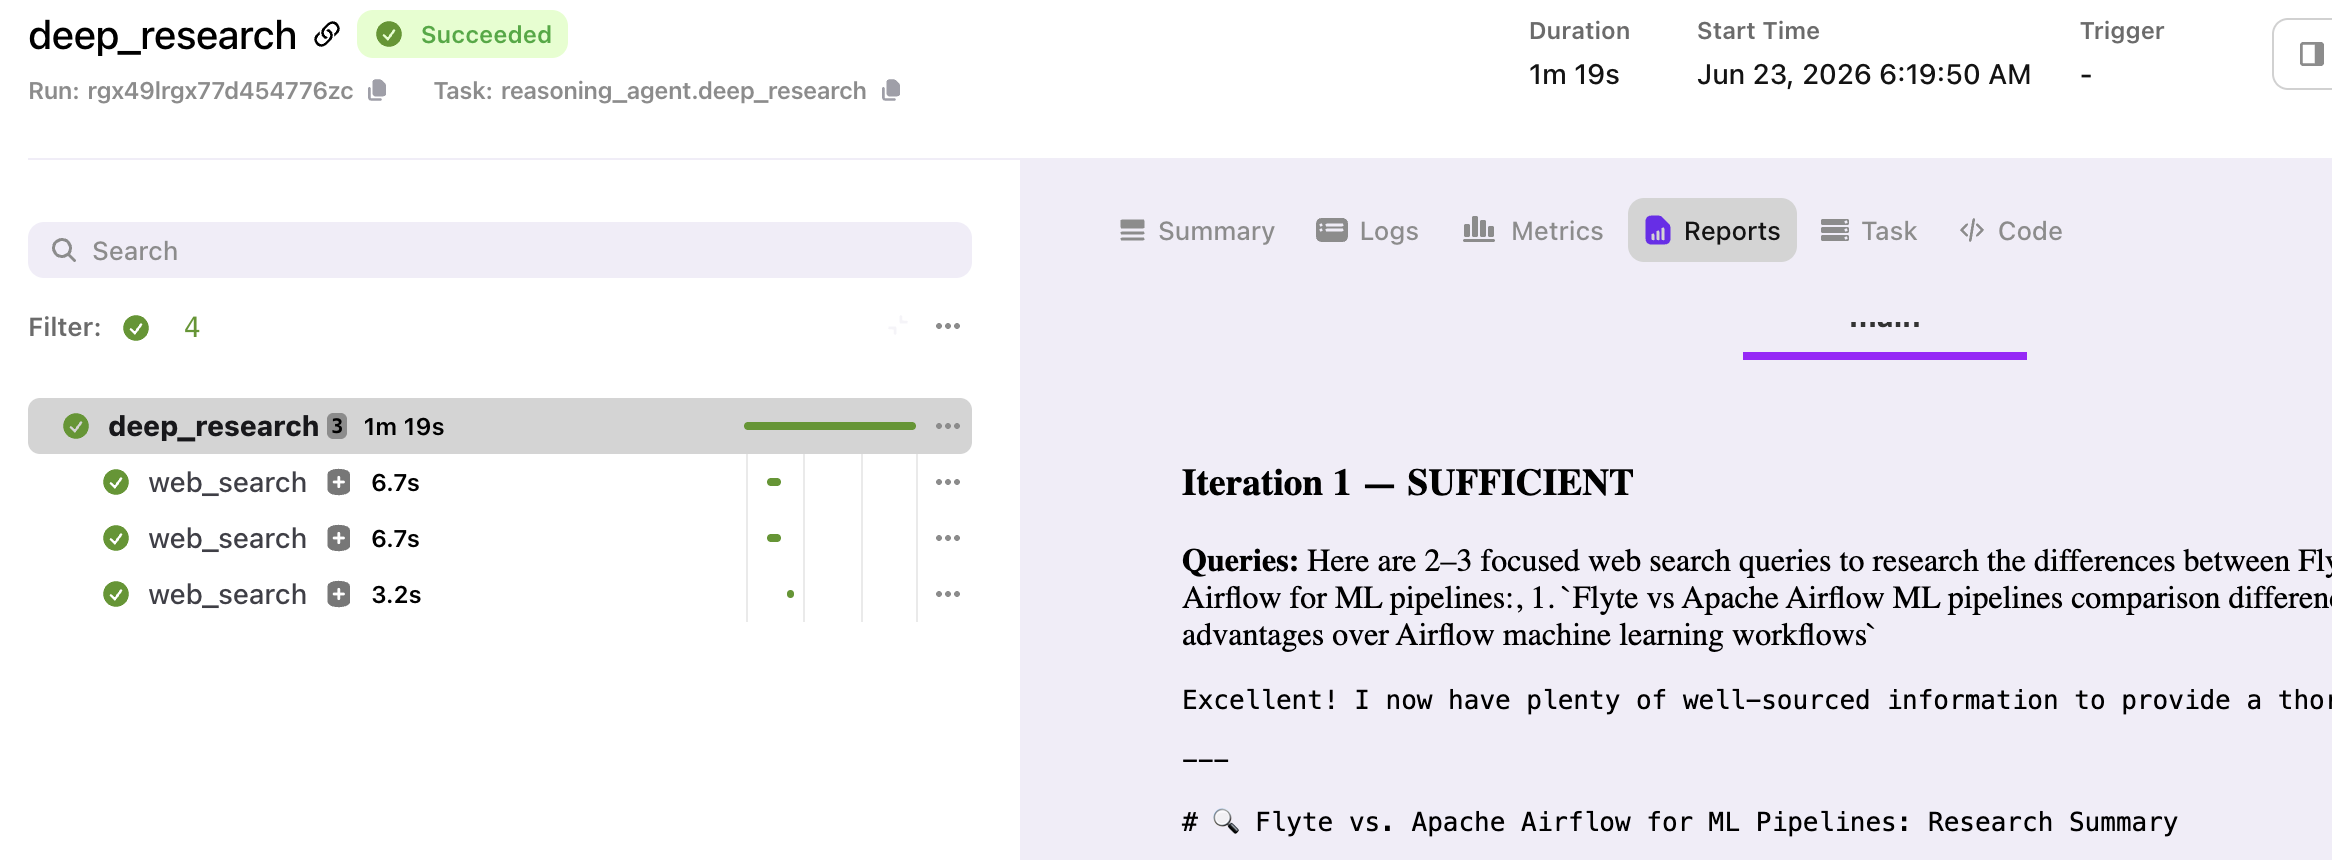

## Scaling the pattern

The devbox runs each task in a fresh container. For production workloads with many short LLM calls, `ReusePolicy` eliminates cold-start overhead by keeping a pool of warm containers ready.

> **Note:** `ReusePolicy` is a Union-specific feature that requires a [Union deployment](https://www.union.ai/docs/v2/union/). It is not supported on the local devbox.

In [ ]:
# Requires a Union deployment — not supported on the local devbox
from datetime import timedelta

production_reasoning_agent = flyte.TaskEnvironment(
    name="reasoning_agent_prod",
    image=_image,
    resources=flyte.Resources(cpu="2", memory="4Gi"),
    secrets=[flyte.Secret(key="ANTHROPIC_API_KEY", as_env_var="ANTHROPIC_API_KEY")],
    reusable=flyte.ReusePolicy(
        replicas=(2, 8),
        concurrency=4,
        scaledown_ttl=timedelta(minutes=5),
        idle_ttl=timedelta(minutes=15),
    ),
)